# Training-free self-assessment score for PGA-UNet on FracAtlas (IMG_SIZE=512)

The built-in QualityHead collapsed to a near-constant estimate, so this notebook
replaces it with a **training-free** score computed from the model's own output at
inference. No weights are changed.

For a prediction with probability map `p`, binary mask `M = (p > 0.5)`, and prompt box `B`:

- `S_sharp` = mean of `2p - 1` over `M` (how decisive the mask is)
- `S_fill`  = area(M in B) / area(M) (does the mask stay inside the prompt)
- `S_size`  = plausibility of area(M) / area(B) (not near-empty, not box-filling)
- `S_stab`  = mean IoU between the mask and `K` masks from small box jitter (consistency)

Headline score `Q = mean(S_sharp, S_stab)` (the two dataset-robust cues). `S_fill`
and `S_size` are still computed and reported alone, and `Q4 = mean of all four` is
shown for comparison, but `S_fill`/`S_size` collapse to a constant when the lesion is
tiny relative to the covering box.

The built-in QualityHead is not read at all (it collapsed to a near-constant value).

**Part A (Claim 9)** correlates `Q` and each sub-signal with the true per-polygon Dice
on the test set.
**Part B (Claim 10)** ranks 50 candidate boxes per image by `Q` and measures how well
the top boxes geometrically cover the ground-truth lesion.

Run in order: **Setup -> Part A -> Part B**.

In [1]:
# -- Setup ---------------------------------------------------------------
%cd /kaggle/working
import os, gdown, torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

if not os.path.exists('PGA_Unet2D'):
    !git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git
else:
    !cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation && git pull -q

PGA_PATH = '/kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation'

DATASET_ID   = '1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv'
DATASET_ROOT = 'dataset_FracAtlas'
if not os.path.exists(f'/kaggle/working/{DATASET_ROOT}'):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}',
                   f'/kaggle/working/{DATASET_ROOT}.zip', quiet=False)
    !unzip -oq /kaggle/working/{DATASET_ROOT}.zip -d /kaggle/working/
!rsync -a /kaggle/working/{DATASET_ROOT}/ {PGA_PATH}/{DATASET_ROOT}/ 2>/dev/null

os.chdir(PGA_PATH)
!pip install -q tqdm opencv-python matplotlib gdown scipy

CKPT_ID   = '1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU'   # PGA-512 `00` (Dice+BCE, has QualityHead)
CKPT_PATH = f'{PGA_PATH}/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_512_best.pth'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
if not os.path.exists(CKPT_PATH):
    gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'\nSetup complete | checkpoint {os.path.getsize(CKPT_PATH)//1024} KB')

/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4770, done.
remote: Counting objects: 100% (552/552), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 4770 (delta 415), reused 447 (delta 381), pack-reused 4218 (from 1)
Receiving objects: 100% (4770/4770), 1.22 GiB | 37.85 MiB/s, done.
Resolving deltas: 100% (2939/2939), done.


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=6eae5829-4aad-4841-b9d7-acfd522823ae
To: /kaggle/working/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:03<00:00, 75.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_512_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 28.5MB/s]


Setup complete | checkpoint 11645 KB


In [2]:
# -- Model + shared helpers -------------------------------------------
import sys, csv
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

for _k in list(sys.modules.keys()):
    if any(x in _k for x in ('dataset', 'models', 'prompt_unet')):
        del sys.modules[_k]
if PGA_PATH in sys.path: sys.path.remove(PGA_PATH)
sys.path.insert(0, PGA_PATH)
from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 512
KERNEL   = 31
DS_NAME  = 'FracAtlas'
TEST_IMG   = f'{PGA_PATH}/{DATASET_ROOT}/test/images'
TEST_JSON  = f'{PGA_PATH}/{DATASET_ROOT}/test/annotations'
RESULT_DIR = f'{PGA_PATH}/results'
os.makedirs(RESULT_DIR, exist_ok=True)

# jitter / combination settings (lower K_STAB to go faster)
K_STAB       = 6      # box-jitter samples for S_stab in Part A
K_STAB_C10   = 4      # box-jitter samples for S_stab in Part B
USE_STAB_C10 = True   # set False to skip S_stab in Part B (much faster)
JITTER_SHIFT = 0.12   # fraction of box side
JITTER_SCALE = 0.10   # +/- fraction
SEED         = 22120196

model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True, use_quality_head=True).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()

def per_sample_dice(logits, target, smooth=1e-5):
    pred = (torch.sigmoid(logits) > 0.5).float()
    tp = (pred * target).sum(dim=(1, 2, 3))
    fp = (pred * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - pred) * target).sum(dim=(1, 2, 3))
    return (2 * tp + smooth) / (2 * tp + fp + fn + smooth)

def corr(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    a, b = a[ok], b[ok]
    if len(a) < 2 or a.std() == 0 or b.std() == 0:
        return float('nan'), float('nan')
    pear = float(np.corrcoef(a, b)[0, 1])
    ra, rb = np.argsort(np.argsort(a)), np.argsort(np.argsort(b))
    spear = float(np.corrcoef(ra, rb)[0, 1])
    return pear, spear

def plateau_heatmap(box, size=IMG_SIZE, kernel=KERNEL):
    hm = np.zeros((size, size), dtype=np.float32)
    x0, y0, x1, y1 = [int(round(v)) for v in box]
    x0, y0 = max(0, x0), max(0, y0); x1, y1 = min(size, x1), min(size, y1)
    if x1 > x0 and y1 > y0:
        hm[y0:y1, x0:x1] = 1.0
        hm = cv2.GaussianBlur(hm, (kernel, kernel), 0)
    return hm

def box_from_heatmap(hm, thr=0.5):
    ys, xs = np.where(hm >= thr)
    if len(xs) == 0:
        return None
    return [xs.min(), ys.min(), xs.max() + 1, ys.max() + 1]

def jitter_boxes(box, k, rng):
    x0, y0, x1, y1 = box
    w, h = x1 - x0, y1 - y0
    out = []
    for _ in range(k):
        sx = rng.uniform(-JITTER_SHIFT, JITTER_SHIFT) * w
        sy = rng.uniform(-JITTER_SHIFT, JITTER_SHIFT) * h
        fs = 1.0 + rng.uniform(-JITTER_SCALE, JITTER_SCALE)
        nw, nh = w * fs, h * fs
        cx, cy = (x0 + x1) / 2 + sx, (y0 + y1) / 2 + sy
        out.append([cx - nw / 2, cy - nh / 2, cx + nw / 2, cy + nh / 2])
    return out

def masks_from_boxes(img_t, boxes, batch=24):
    """img_t: [1,1,H,W] on DEVICE. Returns list of binary masks (np bool)."""
    out = []
    with torch.no_grad():
        for i in range(0, len(boxes), batch):
            chunk = boxes[i:i + batch]
            hm = np.stack([plateau_heatmap(b) for b in chunk])
            hm_t = torch.from_numpy(hm).unsqueeze(1).float().to(DEVICE)
            rep = img_t.expand(len(chunk), 1, IMG_SIZE, IMG_SIZE)
            logits = model(rep, hm_t)
            p = torch.sigmoid(logits)[:, 0].cpu().numpy()
            out.extend([(pi > 0.5) for pi in p])
    return out

def iou(a, b):
    a, b = a.astype(bool), b.astype(bool)
    u = (a | b).sum()
    if u == 0:
        return 0.0   # both empty is not 'stable good' here
    return float((a & b).sum() / u)

def s_sharp(p, m):
    if m.sum() == 0:
        return 0.0
    return float(np.clip(2 * p[m].mean() - 1, 0, 1))

def s_fill(m, box):
    if m.sum() == 0:
        return 0.0
    x0, y0, x1, y1 = [int(round(v)) for v in box]
    x0, y0 = max(0, x0), max(0, y0); x1, y1 = min(IMG_SIZE, x1), min(IMG_SIZE, y1)
    inside = m[y0:y1, x0:x1].sum()
    return float(inside / m.sum())

def s_size(m, box):
    x0, y0, x1, y1 = box
    area_b = max(1.0, (x1 - x0) * (y1 - y0))
    r = m.sum() / area_b   # mask area as a fraction of the prompt box
    # near-empty (r<~0.003) or box-filling (r>~0.7) masks are implausible
    return float(np.clip(min((r - 0.003) / 0.02, (0.72 - r) / 0.35), 0, 1))

def stab_scores(img_t, boxes, base_masks, k, rng):
    """Batched S_stab for many boxes at once. base_masks: list of np bool masks
    already computed for each box. Returns np array of mean-IoU per box."""
    jitter_all, owner = [], []
    for bi, b in enumerate(boxes):
        for jb in jitter_boxes(b, k, rng):
            jitter_all.append(jb); owner.append(bi)
    jmasks = masks_from_boxes(img_t, jitter_all)
    acc = [[] for _ in boxes]
    for o, jm in zip(owner, jmasks):
        acc[o].append(iou(base_masks[o], jm))
    return np.array([np.mean(a) if a else 0.0 for a in acc])

def s_stab(img_t, box, k, rng):
    base = masks_from_boxes(img_t, [box])[0]
    return float(stab_scores(img_t, [box], [base], k, rng)[0])

print('helpers ready | device', DEVICE)

helpers ready | device cuda


## Part A - correlation of the training-free score with true Dice (Claim 9)

center_zoom: done (92 prompts)
center_shift: done (92 prompts)

FracAtlas: correlation with true Dice (Pearson / Spearman)

signal                   center_zoom          center_shift
----------------------------------------------------------
S_sharp              0.568 /   0.472       0.362 /   0.433
S_fill               0.158 /  -0.017         nan /     nan
S_size                 nan /     nan         nan /     nan
S_stab               0.564 /   0.630       0.413 /   0.449
Q4                   0.592 /   0.653       0.436 /   0.478
Q                    0.590 /   0.652       0.436 /   0.478  <-- headline


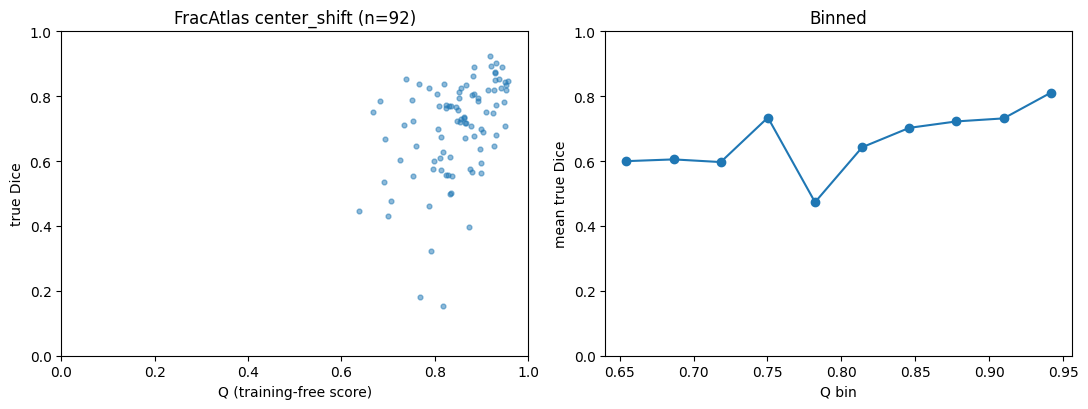

In [3]:
# -- Part A ------------------------------------------------------------
rng = np.random.default_rng(SEED)
rows = []
for prompt_mode in ('center_zoom', 'center_shift'):
    ds = PromptSegmentationDataset(TEST_IMG, TEST_JSON, img_size=IMG_SIZE, is_train=False,
                                  prompt_mode=prompt_mode, scale_factor=3.0, shift_ratio=0.5)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)
    for idx, (image, mask, prompt) in enumerate(loader):
        image_d, prompt_d = image.to(DEVICE), prompt.to(DEVICE)
        with torch.no_grad():
            logits = model(image_d, prompt_d)
        p = torch.sigmoid(logits)[0, 0].cpu().numpy()
        m = p > 0.5
        true_dice = float(per_sample_dice(logits, mask.to(DEVICE))[0].cpu())
        box = box_from_heatmap(prompt[0, 0].numpy())
        if box is None:
            continue
        ss = s_sharp(p, m); sf = s_fill(m, box); sz = s_size(m, box)
        st = s_stab(image_d, box, K_STAB, rng)
        q = float(np.mean([ss, st]))            # headline: two robust cues
        q4 = float(np.mean([ss, sf, sz, st]))   # all four, for comparison
        img_name, poly_idx = ds.all_samples[idx]
        rows.append(dict(dataset=DS_NAME, prompt=prompt_mode, image=img_name, polygon_index=poly_idx,
                         true_dice=true_dice,
                         S_sharp=ss, S_fill=sf, S_size=sz, S_stab=st, Q=q, Q4=q4))
    print(f'{prompt_mode}: done ({len([r for r in rows if r["prompt"]==prompt_mode])} prompts)')

with open(f'{RESULT_DIR}/selfassess_per_polygon_{DS_NAME.lower()}.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)

print(f'\n{DS_NAME}: correlation with true Dice (Pearson / Spearman)\n')
print(f'{"signal":<14}{"center_zoom":>22}{"center_shift":>22}')
print('-' * 58)
for sig in ('S_sharp', 'S_fill', 'S_size', 'S_stab', 'Q4', 'Q'):
    cells = []
    for pm in ('center_zoom', 'center_shift'):
        sub = [r for r in rows if r['prompt'] == pm]
        pe, sp = corr([r[sig] for r in sub], [r['true_dice'] for r in sub])
        cells.append(f'{pe:>10.3f} /{sp:>8.3f}')
    mark = '  <-- headline' if sig == 'Q' else ''
    print(f'{sig:<14}{cells[0]:>22}{cells[1]:>22}{mark}')

# scatter Q vs true Dice (center_shift)
sub = [r for r in rows if r['prompt'] == 'center_shift']
qv = np.array([r['Q'] for r in sub]); td = np.array([r['true_dice'] for r in sub])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(qv, td, s=12, alpha=0.5)
ax[0].set_xlabel('Q (training-free score)'); ax[0].set_ylabel('true Dice')
ax[0].set_title(f'{DS_NAME} center_shift (n={len(sub)})'); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
edges = np.linspace(qv.min(), qv.max(), 11); ctr = (edges[:-1] + edges[1:]) / 2
mdice = [td[(qv >= lo) & (qv < hi)].mean() if ((qv >= lo) & (qv < hi)).any() else np.nan
         for lo, hi in zip(edges[:-1], edges[1:])]
ax[1].plot(ctr, mdice, 'o-'); ax[1].set_xlabel('Q bin'); ax[1].set_ylabel('mean true Dice')
ax[1].set_title('Binned'); ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/selfassess_scatter_{DS_NAME.lower()}.png', dpi=130, facecolor='white')
plt.show()

## Part B - candidate region suggestion ranked by Q (Claim 10)

50 candidate boxes per image, ranked by `Q`. Coverage = fraction of ground-truth
lesion pixels inside a box.

In [4]:
# -- Part B ----------------------------------------------------------
import json as _json
N_CANDIDATES = 50
TOP_KS       = (3, 5)
SIZE_FRAC    = (0.15, 0.55)

def resize_and_pad(arr, size, interp, pad=0):
    h, w = arr.shape[:2]
    sc = min(size / w, size / h)
    nw, nh = max(1, round(w * sc)), max(1, round(h * sc))
    r = cv2.resize(arr, (nw, nh), interpolation=interp)
    out = np.full((size, size), pad, dtype=r.dtype)
    pl, pt = (size - nw) // 2, (size - nh) // 2
    out[pt:pt + nh, pl:pl + nw] = r
    return out

def load_image_and_gt(img_name):
    base = os.path.splitext(img_name)[0]
    img = cv2.imread(os.path.join(TEST_IMG, img_name), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    gt = np.zeros((h, w), dtype=np.uint8)
    with open(os.path.join(TEST_JSON, base + '.json'), encoding='utf-8') as f:
        data = _json.load(f)
    for s in data.get('shapes', []):
        if s.get('shape_type') == 'polygon':
            cv2.fillPoly(gt, [np.array(s['points'], dtype=np.int32)], 1)
    canvas = resize_and_pad(img, IMG_SIZE, cv2.INTER_LINEAR, 0)
    canvas = (canvas.astype(np.float32) / 255.0 - 0.5) / 0.5
    gt512 = (resize_and_pad(gt.astype(np.float32), IMG_SIZE, cv2.INTER_NEAREST, 0.0) > 0.5).astype(np.float32)
    return canvas, gt512

def coverage(box, gt512):
    tot = gt512.sum()
    if tot == 0:
        return None
    x0, y0, x1, y1 = [int(round(v)) for v in box]
    x0, y0 = max(0, x0), max(0, y0); x1, y1 = min(IMG_SIZE, x1), min(IMG_SIZE, y1)
    if x1 <= x0 or y1 <= y0:
        return 0.0
    return float(gt512[y0:y1, x0:x1].sum() / tot)

rng = np.random.default_rng(SEED)
names = sorted(f for f in os.listdir(TEST_IMG)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))
               and os.path.exists(os.path.join(TEST_JSON, os.path.splitext(f)[0] + '.json')))

per_image = []
per_box = []
examples = []
for n_done, img_name in enumerate(names):
    canvas, gt512 = load_image_and_gt(img_name)
    if gt512.sum() == 0:
        continue
    img_t = torch.from_numpy(canvas).unsqueeze(0).unsqueeze(0).to(DEVICE)
    boxes = []
    for _ in range(N_CANDIDATES):
        bw = rng.uniform(*SIZE_FRAC) * IMG_SIZE; bh = rng.uniform(*SIZE_FRAC) * IMG_SIZE
        bx = rng.uniform(0, IMG_SIZE - bw); by = rng.uniform(0, IMG_SIZE - bh)
        boxes.append([bx, by, bx + bw, by + bh])
    # one batched base pass for all candidates
    probs = []
    with torch.no_grad():
        hm = np.stack([plateau_heatmap(b) for b in boxes])
        for i in range(0, len(boxes), 24):
            ch = hm[i:i + 24]
            lt = model(img_t.expand(len(ch), 1, IMG_SIZE, IMG_SIZE),
                       torch.from_numpy(ch).unsqueeze(1).float().to(DEVICE))
            probs.append(torch.sigmoid(lt)[:, 0].cpu().numpy())
    probs = np.concatenate(probs)
    base_masks = [p > 0.5 for p in probs]
    ss = np.array([s_sharp(p, m) for p, m in zip(probs, base_masks)])
    sf = np.array([s_fill(m, b) for m, b in zip(base_masks, boxes)])
    sz = np.array([s_size(m, b) for m, b in zip(base_masks, boxes)])
    if USE_STAB_C10:
        st = stab_scores(img_t, boxes, base_masks, K_STAB_C10, rng)
        q_scores = np.mean(np.stack([ss, st]), axis=0)      # headline Q
    else:
        q_scores = ss.copy()   # S_stab disabled -> Q falls back to S_sharp only
    cov_all = np.array([coverage(b, gt512) for b in boxes])
    rec = dict(dataset=DS_NAME, image=img_name)
    order = np.argsort(-q_scores)
    for k in TOP_KS:
        ck = cov_all[order[:k]]
        rec[f'mean_cov@{k}'] = float(ck.mean())
        rec[f'best_cov@{k}'] = float(ck.max())
        rec[f'full@{k}'] = int(ck.max() >= 0.999)
    per_image.append(rec)
    for _bi in range(len(boxes)):
        per_box.append(dict(dataset=DS_NAME, image=img_name, box_idx=_bi,
                             q=float(q_scores[_bi]), coverage=float(cov_all[_bi])))
    if len(examples) < 6:
        order = np.argsort(-q_scores)
        examples.append(dict(img_name=img_name, canvas=canvas, gt512=gt512,
                             boxes=[boxes[i] for i in order[:3]],
                             scores=[float(q_scores[i]) for i in order[:3]],
                             covs=[float(cov_all[i]) for i in order[:3]]))
    if (n_done + 1) % 25 == 0:
        print(f'  {n_done + 1}/{len(names)} images')

with open(f'{RESULT_DIR}/selfassess_suggestion_perbox_{DS_NAME.lower()}.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(per_box[0].keys())); w.writeheader(); w.writerows(per_box)

with open(f'{RESULT_DIR}/selfassess_suggestion_per_image_{DS_NAME.lower()}.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(per_image[0].keys())); w.writeheader(); w.writerows(per_image)

print(f'\n{DS_NAME}: {len(per_image)} images with a lesion  (candidates ranked by Q)\n')
print(f'{"top-k":<7}{"mean cov":>12}{"mean best cov":>16}{"full-cov rate":>16}')
print('-' * 51)
agg = []
for k in TOP_KS:
    mc = np.mean([r[f'mean_cov@{k}'] for r in per_image])
    bc = np.mean([r[f'best_cov@{k}'] for r in per_image])
    fr = np.mean([r[f'full@{k}'] for r in per_image])
    print(f'{("top-" + str(k)):<7}{mc:>12.4f}{bc:>16.4f}{fr:>15.1%}')
    agg.append(dict(dataset=DS_NAME, top_k=k, mean_coverage=float(mc),
                    mean_best_coverage=float(bc), full_coverage_rate=float(fr)))
with open(f'{RESULT_DIR}/selfassess_suggestion_summary_{DS_NAME.lower()}.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(agg[0].keys())); w.writeheader(); w.writerows(agg)

  25/72 images
  50/72 images

FracAtlas: 72 images with a lesion  (candidates ranked by Q)

top-k      mean cov   mean best cov   full-cov rate
---------------------------------------------------
top-3        0.6755          0.8709          77.8%
top-5        0.6175          0.9021          81.9%


In [5]:
# -- Part B (extended) - off-target box sanity check for Q -------------
# Reuses the exact same 50 random candidate boxes per lesion image already
# scored above (per_box): no new inference, just re-binning data already
# computed in Part B. Question: does a box that misses the lesion get a low Q?
import pandas as pd
from scipy.stats import spearmanr

df_box = pd.DataFrame(per_box)
bins = [(-0.001, 0.05, 'off-target (<5% overlap)'),
        (0.05, 0.5, 'partial (5-50% overlap)'),
        (0.5, 1.001, 'covering (>50% overlap)')]
print(f'{DS_NAME}: {len(df_box)} candidate boxes across {df_box.image.nunique()} lesion images\n')
print(f'{"bin":<28}{"n":>8}{"mean Q":>10}{"median Q":>10}')
print('-' * 56)
for lo, hi, label in bins:
    sub = df_box[(df_box.coverage > lo) & (df_box.coverage <= hi)]
    if len(sub) == 0:
        continue
    print(f'{label:<28}{len(sub):>8}{sub.q.mean():>10.3f}{sub.q.median():>10.3f}')

rho, p = spearmanr(df_box.coverage, df_box.q)
print(f'\nSpearman(coverage, Q) = {rho:.3f} (p={p:.1e}), pooled across all boxes and images')


FracAtlas: 3600 candidate boxes across 72 lesion images

bin                                n    mean Q  median Q
--------------------------------------------------------
off-target (<5% overlap)        2307     0.225     0.000
partial (5-50% overlap)          354     0.342     0.304
covering (>50% overlap)          939     0.588     0.714

Spearman(coverage, Q) = 0.434 (p=3.0e-165), pooled across all boxes and images


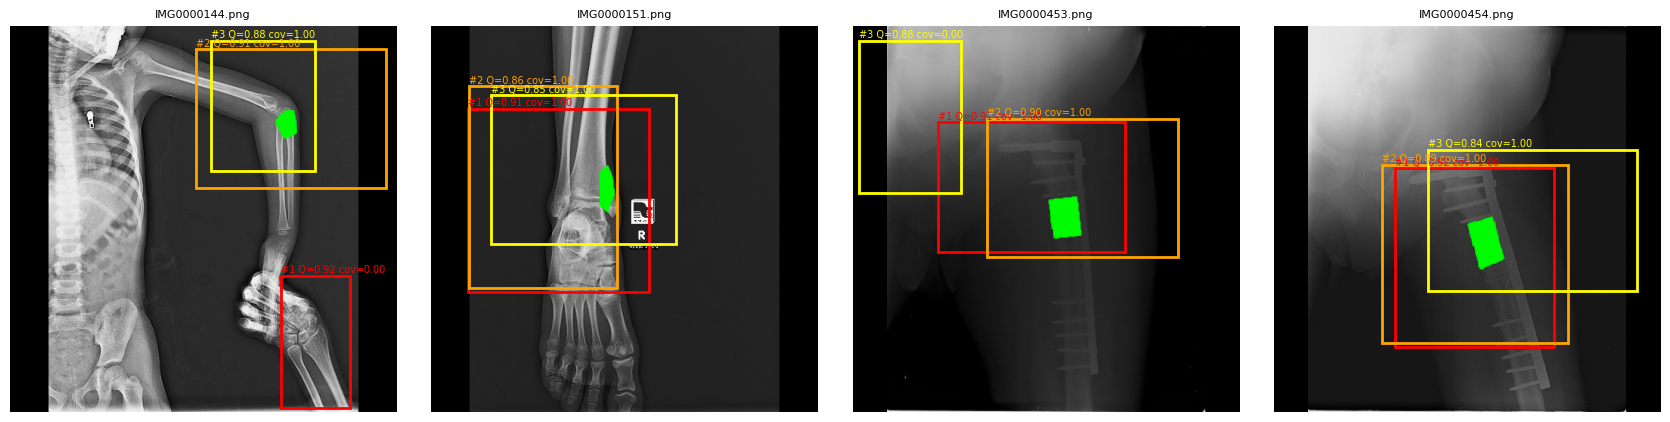

In [6]:
# -- Part B qualitative: top-3 Q-ranked boxes on a few images ---------
from matplotlib.patches import Rectangle
picks = examples[:4]
fig, axes = plt.subplots(1, len(picks), figsize=(4.2 * len(picks), 4.4))
if len(picks) == 1: axes = [axes]
for ax, rec in zip(axes, picks):
    ax.imshow(rec['canvas'] * 0.5 + 0.5, cmap='gray', vmin=0, vmax=1)
    ys, xs = np.where(rec['gt512'] > 0.5)
    if len(xs): ax.scatter(xs, ys, s=1, c='lime', alpha=0.35)
    for r, (b, sc, cv) in enumerate(zip(rec['boxes'], rec['scores'], rec['covs'])):
        x0, y0, x1, y1 = b
        col = ['red', 'orange', 'yellow'][r]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=col, lw=2))
        ax.text(x0, max(0, y0 - 4), f'#{r+1} Q={sc:.2f} cov={cv:.2f}', color=col, fontsize=7)
    ax.set_title(rec['img_name'], fontsize=8); ax.axis('off')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/selfassess_suggestion_examples_{DS_NAME.lower()}.png', dpi=130, facecolor='white')
plt.show()